# 1BM110 - Assignment 1 - Group 7

**Students & IDs** \
Kazimir Breuer - 1574639 \
Daphne Gomes de Mesquita - 1678507 \
Isabelle Weenink - 1722239  \
Renske Quekel - 1529617

**Date** \
10th of March 2026

## Import Libraries


In [152]:
# Import libraries
import pandas as pd
import numpy as np  
import plotly.express as px
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt


#Required for step 4
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

#Required for step 5
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Load dataset

## Load dataset

In [153]:
# Load datasets
df   = pd.read_csv('energy_generation_train.csv')  # train set
test = pd.read_csv('energy_generation_test.csv')   # test set

# Display the first few rows of the training dataset
print("Train set:")
display(df.head())

print("Test set:")
display(test.head())

Train set:


,DateTime,Biomass,Fossil Brown coal/Lignite,Fossil Coal-derived gas,Fossil Gas,Fossil Hard coal,Fossil Oil,Fossil Oil shale,Fossil Peat,Geothermal,...,Hydro Run-of-river and poundage,Hydro Water Reservoir,Marine,Nuclear,Other,Other renewable,Solar,Waste,Wind Offshore,Wind Onshore
0,2023-01-01 00:00:00,0.0,NaN,NaN,919.0,1225.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,485.0,161.0,NaN,1.0,69.0,1893.0,807.0
1,2023-01-01 00:15:00,0.0,NaN,NaN,921.0,1235.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,485.0,139.0,NaN,1.0,70.0,1367.0,741.0
2,2023-01-01 00:30:00,0.0,NaN,NaN,922.0,1249.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,485.0,139.0,NaN,1.0,69.0,1052.0,686.0
3,2023-01-01 00:45:00,0.0,NaN,NaN,966.0,1254.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,485.0,140.0,NaN,1.0,68.0,1090.0,682.0
4,2023-01-01 01:00:00,0.0,NaN,NaN,999.0,1258.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,485.0,137.0,NaN,1.0,68.0,1082.0,760.0


Test set:


,DateTime,Biomass,Fossil Brown coal/Lignite,Fossil Coal-derived gas,Fossil Gas,Fossil Hard coal,Fossil Oil,Fossil Oil shale,Fossil Peat,Geothermal,...,Hydro Run-of-river and poundage,Hydro Water Reservoir,Marine,Nuclear,Other,Other renewable,Solar,Waste,Wind Offshore,Wind Onshore
0,2024-02-01 00:00:00,0.0,NaN,NaN,1795.0,950.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,486.0,185.0,NaN,0.0,69.0,3260.0,1207.0
1,2024-02-01 00:15:00,0.0,NaN,NaN,1586.0,958.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,486.0,206.0,NaN,0.0,70.0,3269.0,1199.0
2,2024-02-01 00:30:00,0.0,NaN,NaN,1349.0,1055.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,486.0,208.0,NaN,0.0,69.0,3272.0,1180.0
3,2024-02-01 00:45:00,0.0,NaN,NaN,1264.0,997.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,486.0,184.0,NaN,0.0,64.0,3275.0,1180.0
4,2024-02-01 01:00:00,0.0,NaN,NaN,1278.0,982.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,486.0,184.0,NaN,0.0,61.0,3277.0,1183.0


## Ensure correct datatypes

In [154]:
# Ensure all columns have the correct data type for both sets
for dataset in [df, test]:
    dataset['DateTime'] = pd.to_datetime(dataset['DateTime'])
    numeric_cols = dataset.columns.drop('DateTime')
    dataset[numeric_cols] = dataset[numeric_cols].apply(pd.to_numeric, errors='coerce')


# Verify data types are correct now
print("Train set:")
display(pd.DataFrame({'Data Type': df.dtypes}))

print("Test set:")
display(pd.DataFrame({'Data Type': test.dtypes}))

Train set:


,Data Type
DateTime,datetime64[us]
Biomass,float64
Fossil Brown coal/Lignite,float64
Fossil Coal-derived gas,float64
Fossil Gas,float64
Fossil Hard coal,float64
Fossil Oil,float64
Fossil Oil shale,float64
Fossil Peat,float64
Geothermal,float64


Test set:


,Data Type
DateTime,datetime64[us]
Biomass,float64
Fossil Brown coal/Lignite,float64
Fossil Coal-derived gas,float64
Fossil Gas,float64
Fossil Hard coal,float64
Fossil Oil,float64
Fossil Oil shale,float64
Fossil Peat,float64
Geothermal,float64


## Keep non-renewable sources 

 

In [155]:
# Keep only datetime and the non-renewable energy sources

cols = ['DateTime', 'Fossil Gas', 'Fossil Hard coal', 'Nuclear']
df   = df[cols]
test = test[cols]

## Display basic statistics

In [156]:
# Describe basic statistics of numerical variables
def describe_extended(dataset, name):
    num_cols = dataset.select_dtypes(include='number').columns
    stats = dataset[num_cols].describe()
    stats.loc['missing'] = dataset[num_cols].isna().sum()
    stats.loc['missing %'] = (dataset[num_cols].isna().mean() * 100).round(2)
    stats.loc['zeros'] = dataset[num_cols].eq(0).sum()
    stats.loc['zeros %'] = (dataset[num_cols].eq(0).mean() * 100).round(2)
    print(f"{name}:")
    display(stats)

describe_extended(df, "Train set")
describe_extended(test, "Test set")


Train set:


,Fossil Gas,Fossil Hard coal,Nuclear
count,36165.000000,36165.000000,36166.000000
mean,3512.526780,1362.925702,433.143837
std,2256.922636,999.446391,135.731203
min,0.000000,0.000000,0.000000
25%,1525.000000,545.000000,470.000000
50%,2874.000000,1204.000000,475.000000
75%,5263.000000,2147.000000,484.000000
max,9666.000000,3912.000000,490.000000
missing,27.000000,27.000000,26.000000
missing %,0.070000,0.070000,0.070000


Test set:


,Fossil Gas,Fossil Hard coal,Nuclear
count,33273.000000,33271.000000,33273.000000
mean,3523.873561,1239.446575,380.551198
std,2435.205330,1167.231757,192.315344
min,0.000000,0.000000,0.000000
25%,1509.000000,280.000000,466.000000
50%,2706.000000,880.000000,475.000000
75%,5148.000000,2041.000000,485.000000
max,11004.000000,3926.000000,491.000000
missing,43.000000,45.000000,43.000000
missing %,0.130000,0.140000,0.130000


# 2. Pre-processing

## Add total energy column
A total energy column is added that sums the three non-renewable energy sources. 

In [157]:
# Make total energy column by summing the three non-renewable energy sources
df['Total_Energy'] = df['Fossil Gas'] + df['Fossil Hard coal'] + df['Nuclear']
test['Total_Energy'] = test['Fossil Gas'] + test['Fossil Hard coal'] + test['Nuclear']

## Handle Datetime

First the datetime is converted to the correct datetime type. Second, the datasets are sorted chronologically. 

In [158]:
# Convert DateTime to proper type (reset index if DateTime ended up as index)
def fix_datetime(dataset, label):
    if dataset.index.name == 'DateTime':
        dataset = dataset.reset_index()
    dataset['DateTime'] = pd.to_datetime(dataset['DateTime'])
    print(f"{label}: DateTime dtype = {dataset['DateTime'].dtype}")
    return dataset

df   = fix_datetime(df,   "Train")
test = fix_datetime(test, "Test")

Train: DateTime dtype = datetime64[us]
Test: DateTime dtype = datetime64[us]


## Fill missing values

In [159]:
print("Train set - missing values per column:")
print(df.isnull().sum())

print("\nTest set - missing values per column:")
print(test.isnull().sum())

# Interpolate missing values for non-renewable sources
energy_cols = ['Fossil Gas', 'Fossil Hard coal', 'Nuclear']
for dataset in [df, test]:
    dataset[energy_cols] = dataset[energy_cols].interpolate(method='linear')

# Recalculate Total_Energy based on interpolated values
df['Total_Energy']   = df['Fossil Gas']   + df['Fossil Hard coal']   + df['Nuclear']
test['Total_Energy'] = test['Fossil Gas'] + test['Fossil Hard coal'] + test['Nuclear']


Train set - missing values per column:
DateTime             0
Fossil Gas          27
Fossil Hard coal    27
Nuclear             26
Total_Energy        28
dtype: int64

Test set - missing values per column:
DateTime             0
Fossil Gas          43
Fossil Hard coal    45
Nuclear             43
Total_Energy        45
dtype: int64


## Complete timestamps
First the duplicate timestamps are removed. Second, the missing timestamps are checked. The missing timestamps are added and the values are caclulated by performing linear interpolation. 

### Remove duplicate timestamps

In [160]:
# Remove duplicate timestamps (keep first occurrence)
def remove_duplicate_timestamps(dataset, label):
    n_before = len(dataset)
    cleaned = (dataset
               .drop_duplicates(subset='DateTime', keep='first')
               .sort_values('DateTime')
               .reset_index(drop=True))
    n_removed = n_before - len(cleaned)
    print(f"[{label}] Duplicate timestamps removed: {n_removed}  ({n_before} → {len(cleaned)} rows)")
    return cleaned

df   = remove_duplicate_timestamps(df,   "Train")
test = remove_duplicate_timestamps(test, "Test")

[Train] Duplicate timestamps removed: 0  (36192 → 36192 rows)
[Test] Duplicate timestamps removed: 4  (33316 → 33312 rows)


### Add missing timestamps

In [161]:

# Add missing timestamps (fill gaps with linear interpolation, every 15 minutes)
def add_missing_timestamps(dataset, label):
    full_range = pd.date_range(start=dataset['DateTime'].min(),
                               end=dataset['DateTime'].max(),
                               freq='15min')
    n_original = len(dataset)
    n_expected = len(full_range)
    n_added    = n_expected - n_original

    dataset = (dataset
               .set_index('DateTime')
               .reindex(full_range)
               .rename_axis('DateTime')
               .interpolate(method='linear')
               .reset_index())

    print(f"[{label}] Missing timestamps added: {n_added}  ({n_original} → {n_expected} rows)")
    return dataset

df   = add_missing_timestamps(df,   "Train")
test = add_missing_timestamps(test, "Test")


[Train] Missing timestamps added: 1824  (36192 → 38016 rows)
[Test] Missing timestamps added: 1824  (33312 → 35136 rows)


## Transform data (normalization)

In [162]:
# Scale/normalize features (fit on train, apply to both)
test = test.copy()

# 1. Initialize the scaler
scaler = MinMaxScaler(feature_range=(0, 1))

# 2. Select numeric columns (excluding DateTime)
numeric_cols = df.select_dtypes(include=['number']).columns

# 3. Fit on train, transform both
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
test[numeric_cols] = scaler.transform(test[numeric_cols])  # transform only, no re-fit

# 4. Verify scaling
print("Train set statistics:")
print(df[numeric_cols].describe().loc[['min', 'max']])

print("\nTest set statistics:")
print(test[numeric_cols].describe().loc[['min', 'max']])

Train set statistics:
     Fossil Gas  Fossil Hard coal  Nuclear  Total_Energy
min         0.0               0.0      0.0           0.0
max         1.0               1.0      1.0           1.0

Test set statistics:
     Fossil Gas  Fossil Hard coal   Nuclear  Total_Energy
min    0.000000          0.000000  0.000000      0.000000
max    1.138423          1.003579  1.002041      1.160115


# 3. Organize time-dependent data

## Create windows

In [163]:
#Data is already sorted by time

# Create sequences/windows for time series
def create_sequences(df, sequence_length):
    """
    Converts a 2D dataframe into 3D arrays for RNN input.
    """
    # Extract only the numerical features (ignore DateTime for the math)
    data = df.select_dtypes(include=[np.number]).values
    
    X, y = [], []
    
    # Slide the window across the data
    for i in range(len(data) - sequence_length):
        # The past 'sequence_length' steps
        X.append(data[i : i + sequence_length])
        # The very next step after the window (predicting all features)
        y.append(data[i + sequence_length])
        
    return np.array(X), np.array(y)

# Set window size to 24 hours (96 steps of 15-minutes)
SEQ_LENGTH = 96

# Create sequences for the train set (df) and test set (test)
X_data, y_data = create_sequences(df, SEQ_LENGTH)
X_test, y_test = create_sequences(test, SEQ_LENGTH)

print(f"Original df shape: {df.shape}")
print(f"X_data (Features) shape: {X_data.shape} -> (Samples, Timesteps, Features)")
print(f"y_data (Targets) shape: {y_data.shape} -> (Samples, Features)")
print(f"Original test shape: {test.shape}")
print(f"X_test (Features) shape: {X_test.shape} -> (Samples, Timesteps, Features)")
print(f"y_test (Targets) shape: {y_test.shape} -> (Samples, Features)")

Original df shape: (38016, 5)
X_data (Features) shape: (37920, 96, 4) -> (Samples, Timesteps, Features)
y_data (Targets) shape: (37920, 4) -> (Samples, Features)
Original test shape: (35136, 5)
X_test (Features) shape: (35040, 96, 4) -> (Samples, Timesteps, Features)
y_test (Targets) shape: (35040, 4) -> (Samples, Features)


## Visualize windowing strategy

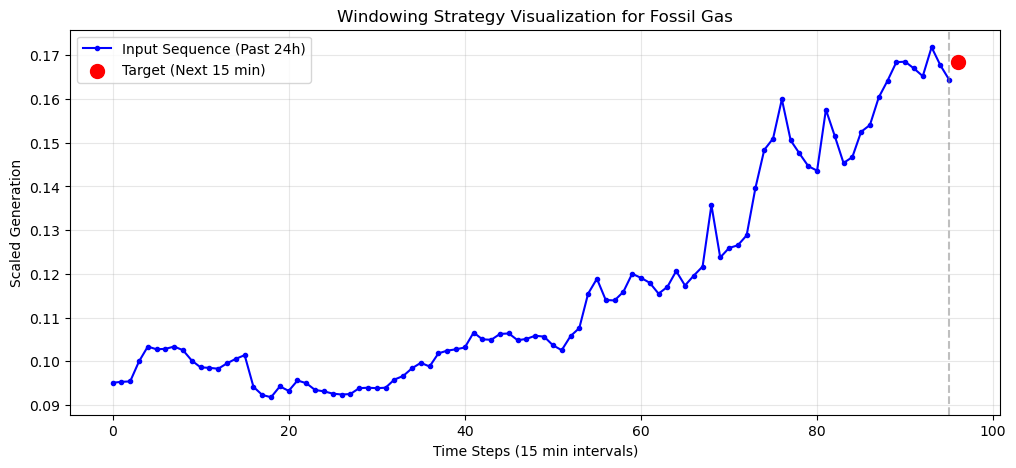

In [164]:
# Visualize the windowing strategy
# Let's visualize the very first sequence and its target for a specific feature
feature_idx = 0 # 'Fossil Gas' (assuming it's the first numerical column)
feature_name = df.select_dtypes(include=[np.number]).columns[feature_idx]

plt.figure(figsize=(12, 5))

# Plot the 96 steps of the input sequence (X)
plt.plot(range(SEQ_LENGTH), X_data[0, :, feature_idx], label='Input Sequence (Past 24h)', color='blue', marker='.')

# Plot the 1 step of the target (y)
plt.scatter(SEQ_LENGTH, y_data[0, feature_idx], color='red', s=100, label='Target (Next 15 min)', zorder=5)

plt.axvline(x=SEQ_LENGTH-1, color='gray', linestyle='--', alpha=0.5)
plt.title(f'Windowing Strategy Visualization for {feature_name}')
plt.xlabel('Time Steps (15 min intervals)')
plt.ylabel('Scaled Generation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 4. Prepare data or model selection and evaluation

## Split data

In [165]:
# Calculate indices for a 70/15/15 split
n = len(X_data)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

# Split the data chronologically
X_train, y_train = X_data[:train_end], y_data[:train_end]
X_val,   y_val   = X_data[train_end:val_end], y_data[train_end:val_end]
X_test_internal, y_test_internal = X_data[val_end:], y_data[val_end:]

print(f"Training set:   {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Internal Test:  {X_test_internal.shape}")

Training set:   (26544, 96, 4)
Validation set: (5688, 96, 4)
Internal Test:  (5688, 96, 4)


## Organize model architecture

In [166]:
# 1. Define Model Architecture
model = Sequential([
    # Input shape is (96 timesteps, 9 features)
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    
    # First LSTM layer (returns sequences for the next LSTM)
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    
    # Second LSTM layer
    LSTM(32),
    Dropout(0.1),
    
    # Fully connected layer
    Dense(16, activation='relu'),
    
    # Output layer (predicts the next value for all 9 features)
    Dense(X_train.shape[2])
])

# 2. Compile Model
model.compile(
    optimizer='adam', 
    loss='mse',      # Mean Squared Error for regression
    metrics=['mae']  # Mean Absolute Error for readability
)

# 3. Display Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 96, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 96, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,676 (119.83 KB)

 Trainable params: 30,676 (119.83 KB)

 Non-trainable params: 0 (0.00 B)

# 5. RNN architecture

In [167]:
# 1. Setup Early Stopping to prevent overfitting
# This will stop training if the validation loss doesn't improve for 5 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# 2. Train the model
# We use a batch_size of 32 and run for up to 50 epochs
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
830/830 ━━━━━━━━━━━━━━━━━━━━ 34s 38ms/step - loss: 0.0382 - mae: 0.1174 - val_loss: 0.0019 - val_mae: 0.0334
Epoch 2/50
830/830 ━━━━━━━━━━━━━━━━━━━━ 32s 39ms/step - loss: 0.0028 - mae: 0.0394 - val_loss: 9.7424e-04 - val_mae: 0.0211
Epoch 3/50
830/830 ━━━━━━━━━━━━━━━━━━━━ 33s 40ms/step - loss: 0.0018 - mae: 0.0312 - val_loss: 0.0011 - val_mae: 0.0261
Epoch 4/50
830/830 ━━━━━━━━━━━━━━━━━━━━ 34s 41ms/step - loss: 0.0013 - mae: 0.0264 - val_loss: 9.0158e-04 - val_mae: 0.0228
Epoch 5/50
830/830 ━━━━━━━━━━━━━━━━━━━━ 34s 41ms/step - loss: 0.0010 - mae: 0.0233 - val_loss: 8.1206e-04 - val_mae: 0.0213
Epoch 6/50
830/830 ━━━━━━━━━━━━━━━━━━━━ 34s 41ms/step - loss: 8.8329e-04 - mae: 0.0212 - val_loss: 7.2232e-04 - val_mae: 0.0200
Epoch 7/50
830/830 ━━━━━━━━━━━━━━━━━━━━ 34s 41ms/step - loss: 8.0096e-04 - mae: 0.0199 - val_loss: 6.3859e-04 - val_mae: 0.0169
Epoch 8/50
830/830 ━━━━━━━━━━━━━━━━━━━━ 35s 42ms/step - loss: 7.3201e-04 - mae: 0.0190 - val_loss: 8.5399e-04 - val_mae: 0.0225
Epoc

178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step


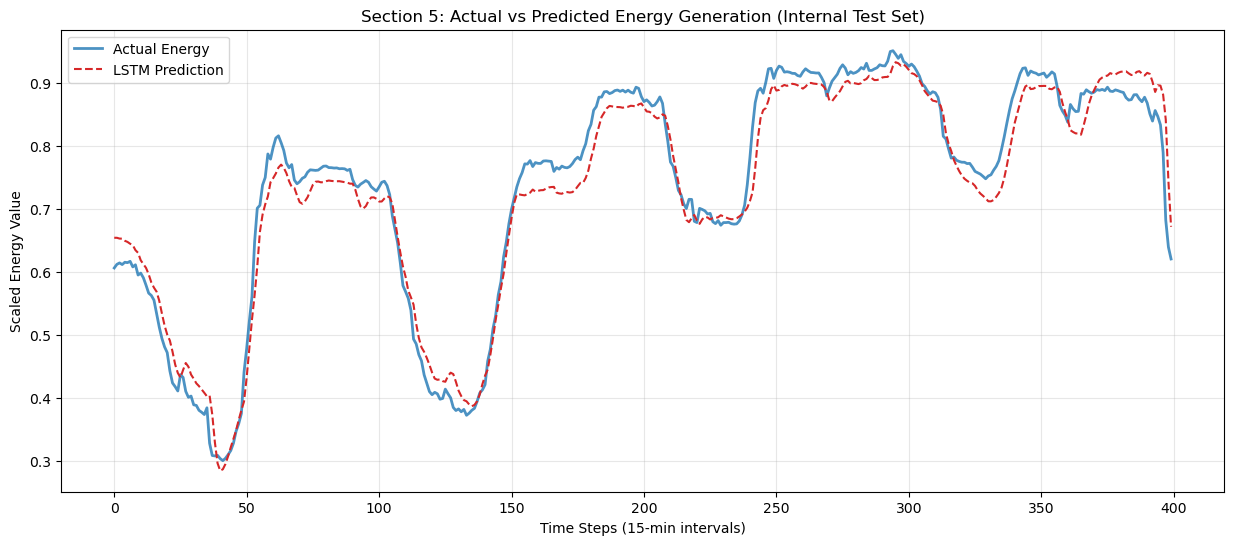

In [168]:
# Make predictions on the internal test set first
predictions_internal = model.predict(X_test_internal)

# Select the 'Total_Energy' index (it's the last one: -1)
target_idx = -1 

plt.figure(figsize=(15, 6))

# Plotting 400 points (about 4 days) so you can actually see the 15-min intervals
plt.plot(y_test_internal[:400, target_idx], label='Actual Energy', color='#1f77b4', alpha=0.8, linewidth=2)
plt.plot(predictions_internal[:400, target_idx], label='LSTM Prediction', color='#d62728', linestyle='--', alpha=1)

plt.title('Section 5: Actual vs Predicted Energy Generation (Internal Test Set)')
plt.xlabel('Time Steps (15-min intervals)')
plt.ylabel('Scaled Energy Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

NameError: name 'predictions' is not defined

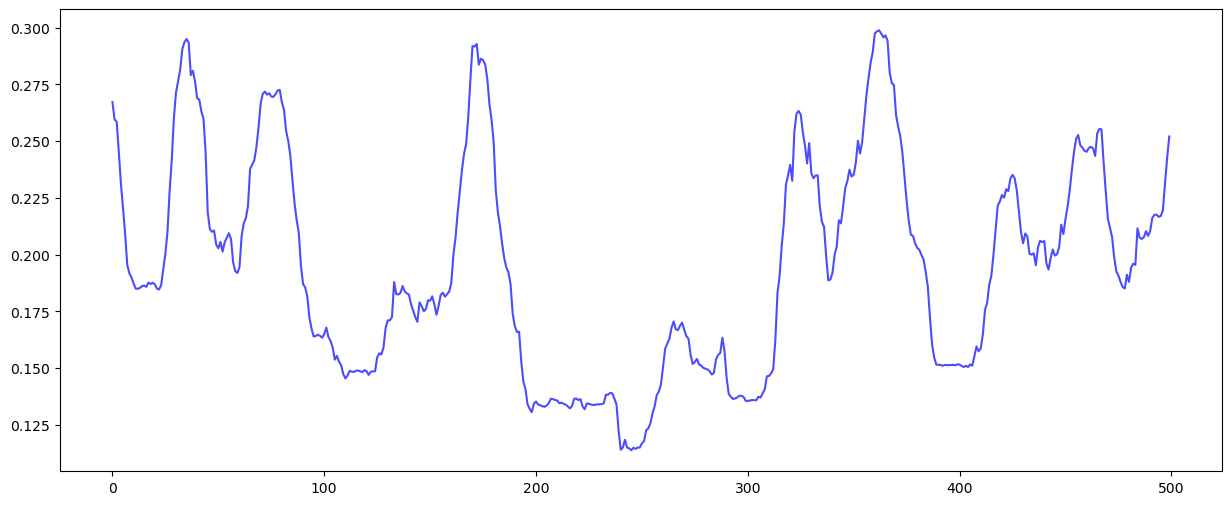

In [169]:
# Select the 'Total_Energy' index (usually the last index)
target_idx = -1 
feature_name = df.columns[target_idx + 1] # Offset for DateTime

plt.figure(figsize=(15, 6))
# Plotting the first 500 points for clarity
plt.plot(y_test[:500, target_idx], label='Actual', color='blue', alpha=0.7)
plt.plot(predictions[:500, target_idx], label='Predicted', color='red', linestyle='--', alpha=0.9)

plt.title(f'Actual vs Predicted Energy Generation ({feature_name})')
plt.xlabel('Time Steps (15-min intervals)')
plt.ylabel('Scaled Energy Value')
plt.legend()
plt.show()


# 6. Training and validation losses

In [ ]:
# Section 6: Plotting Training and Validation Losses
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss', color='royalblue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='darkorange', linewidth=2)

plt.title('Section 6: Model Training & Validation Loss', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (Mean Squared Error)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Select a window of 48 hours (4 steps per hour * 48 hours = 192 steps)
window = 192 

# Choose the feature to plot (Total_Energy is typically the last column: index -1)
target_col_index = -1
target_name = "Total Energy"

plt.figure(figsize=(15, 6))

# Plot Actual values
plt.plot(y_test_internal[:window, target_col_index], 
         label='Actual (Ground Truth)', 
         color='#1f77b4', linewidth=2, marker='o', markersize=4, alpha=0.8)

# Plot Predicted values
plt.plot(predictions[:window, target_col_index], 
         label='LSTM Prediction', 
         color='#d62728', linestyle='--', linewidth=2, marker='x', markersize=4)

plt.title(f'48-Hour Forecast: Actual vs. Predicted {target_name} (15-min intervals)', fontsize=14)
plt.xlabel('Time Steps (Each step = 15 minutes)', fontsize=12)
plt.ylabel('Scaled Energy Value', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, which='both', linestyle='--', alpha=0.5)

# Optional: Add vertical lines every 24 hours (96 steps) to show daily cycles
plt.axvline(x=96, color='gray', linestyle='-', alpha=0.3, label='24h Mark')

plt.tight_layout()
plt.show()

# 7. Evaluation model performance

In [ ]:
# Make predictions on test set

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np

# 1. Make predictions on the external test set
final_predictions = model.predict(X_test)

# 2. Calculate Advanced Metrics
mae = mean_absolute_error(y_test, final_predictions)
mse = mean_squared_error(y_test, final_predictions)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, final_predictions)
r2 = r2_score(y_test, final_predictions)

print("--- Final Model Evaluation (External Test Set) ---")
print(f"Mean Absolute Error (MAE):      {mae:.4f}")
print(f"Mean Squared Error (MSE):       {mse:.4f}")
print(f"Root Mean Squared Error (RMSE):  {rmse:.4f}")
print(f"Mean Absolute % Error (MAPE):   {mape:.4f} ({mape*100:.2f}%)")
print(f"R² Score (Coefficient of Det.): {r2:.4f}")

# 3. Create a summary table
metrics_results = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'MAPE', 'R² Score'],
    'Value': [mae, mse, rmse, f"{mape*100:.2f}%", r2]
})
display(metrics_results)

# 8. Plot model predictions vs. test set